In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/breast_cancer.csv')

# 확인
df


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [ ]:
df2=df.drop('label',axis=1)   # label 열을 제거한 데이터를 df2에 저장
df.head()                     # df의 상위 5개 행을 출력


,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
y=df2['worst compactness']    # worst compactness 열을 타깃값(y)으로 저장
y.value_counts()          # worst compactness 값들의 개수 확인
y

,worst compactness
0,0.66560
1,0.18660
2,0.42450
3,0.86630
4,0.20500
...,...
564,0.21130
565,0.19220
566,0.30940
567,0.86810


In [ ]:
X=df2.drop('worst compactness',axis=1)  # worst compactness 열을 제외한 나머지 열을 입력값(X)으로 저장
X.head()                    # X의 상위 5개 행을 출력

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.009208,14.91,26.50,98.87,567.7,0.2098,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.4000,0.1625,0.2364,0.07678


In [ ]:
scaler = StandardScaler() # 각 특성(열)의 평균을 0, 표준편차를 1로 맞추기 위한 객체 생성
X = scaler.fit_transform(X) # 그 값을 이용해 데이터를 표준화(transform)

In [ ]:
# y의 범주형 값을 원-핫 인코딩(One-Hot Encoding)으로 변환한 뒤
# 넘파이 배열 형태로 저장
Y = pd.get_dummies(y).values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455, 529), (114, 30), (114, 529))

In [ ]:
# 모델 정의

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

# Sequential 모델 생성
# 층을 순서대로 쌓는 가장 기본적인 신경망 모델
model = Sequential()

# 입력층 + 첫 번째 은닉층
# 뉴런 8개, 입력 데이터의 특성 개수는 X.shape[1]
# 활성화 함수는 ReLU 사용
model.add(Dense(8, input_shape=(X.shape[1],), activation='relu'))

# 두 번째 은닉층
# 뉴런 30개, 활성화 함수는 ReLU
model.add(Dense(30, activation='relu'))

# 세 번째 은닉층
# 뉴런 30개, 활성화 함수는 ReLU
model.add(Dense(30, activation='relu'))

# 출력층
# 뉴런 1개이므로 회귀 문제에 적합한 형태
model.add(Dense(1))

# 모델 학습 설정
# optimizer: 가중치 갱신 방법으로 rmsprop 사용
# loss: 손실 함수로 평균제곱오차(mse) 사용
# metrics: 학습 과정에서 mse를 함께 출력
model.compile(optimizer='rmsprop', loss='mse', metrics=['mse'])

# 모델 구조 요약 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,479 (5.78 KB)

 Trainable params: 1,479 (5.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0823 - mse: 0.0823 - val_loss: 0.0157 - val_mse: 0.0157
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0234 - mse: 0.0234 - val_loss: 0.0067 - val_mse: 0.0067
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0113 - mse: 0.0113 - val_loss: 0.0051 - val_mse: 0.0051
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0067 - mse: 0.0067 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - mse: 0.0044 - val_loss: 0.0038 - val_mse: 0.0038
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mse: 0.0031 - val_loss: 0.0030 - val_mse: 0.0030
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - mse: 0.0027 - val_loss: 0.0027 - val_mse: 0.0027
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - mse: 0.0025 - val_loss: 0.0043 - val_mse: 0.0043
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - mse:

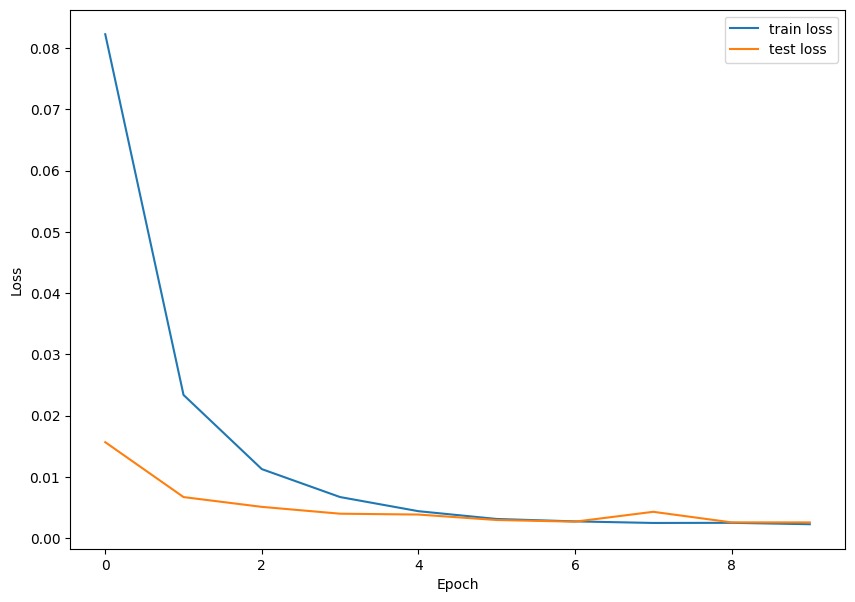

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - mse: 0.0026


[0.002567230723798275, 0.002567230723798275]